# Historical wind-plus-solar conditions: an educational Dunkelflaute benchmark

This notebook is the next historical step in **EuroGrid-Climate-Dynamics**. It asks a practical climate-and-renewables question:

> During the five pilot winters, when did the ERA5 weather proxy indicate simultaneously weak wind and weak surface solar input, and how similar were those periods to low renewable output in SMARD?

The notebook deliberately separates three ideas:

1. **Weather resource:** ERA5 wind speed and downward surface shortwave irradiance.
2. **Simple renewable proxy:** transparent, normalized indices derived from those fields.
3. **Observed generation:** SMARD generation divided by installed capacity.

The proxy is not a plant-level power model. It does not represent turbine or panel locations, power curves for every technology, wakes, availability, curtailment, storage, imports, or grid constraints. The five winters are a **pilot benchmark**, not a multi-decadal climatology. Associations with TM1990 blocking are descriptive and are not causal attribution.

## How to read this notebook

Each section follows the same four questions:

1. **What did we download?**
2. **What calculation did we perform?**
3. **What does the figure or table show in plain language?**
4. **What can we not conclude?**

The key new ERA5 field is `ssrd`: **surface solar radiation downwards**. ARCO stores it as hourly accumulated energy in J m⁻². The loader converts it to mean hourly downward shortwave irradiance in W m⁻². We call this `ssrd` throughout; we do not silently rename it “GHI”, although it is a physically related horizontal-surface solar-resource quantity.

In [1]:
# Purpose: import the canonical loaders, diagnostics, and plotting tools used below.
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr
import yaml
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "config/settings.yaml").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

from eurogrid.data.era5 import load_era5, load_era5_z500
from eurogrid.data.smard import SmardClient, capacity_factor
from eurogrid.diagnostics.blocking import detect_tm1990, persistence_summary
from eurogrid.models.transfer import FLEET_BOXES, PowerCurve, fleet_wind_speed

with open(ROOT / "config/settings.yaml") as handle:
    cfg = yaml.safe_load(handle)

windows = cfg["blocking"]["benchmark_windows"]
thresholds = cfg["dunkelflaute"]["capacity_factor_thresholds"]
durations = cfg["dunkelflaute"]["min_duration_hours"]


## 1. What the ERA5 variables mean

| Field | Plain-language meaning | Unit after loading | Role here |
|---|---|---:|---|
| `ws100` | wind speed at 100 m above the surface | m s⁻¹ | offshore wind-resource proxy |
| `ssrd` | downward shortwave energy arriving at the surface, averaged over each hour | W m⁻² | solar-resource proxy |
| `z500` | geopotential height at 500 hPa | m | existing TM1990 blocking diagnostic |

The wind and solar fields are spatially averaged separately. Wind uses the existing North Sea offshore box. Solar uses the existing broad German land-proxy box from the transfer model. This is deliberately transparent, but it is not a capacity-weighted plant map.

In [2]:
# Purpose: load one complete December–February ERA5 window per pilot winter through the existing canonical cache.
era5_by_winter = {}
inventory_rows = []
for window in windows:
    ds = load_era5(
        datetime.fromisoformat(window["start"]),
        datetime.fromisoformat(window["end"]),
        **cfg["domain"],
        cache_dir=ROOT / cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
    era5_by_winter[window["label"]] = ds
    inventory_rows.append(
        {
            "winter": window["label"],
            "hourly_timesteps": ds.sizes["time"],
            "z500_timesteps": ds.sizes["time_z500"],
            "latitudes": ds.sizes["lat"],
            "longitudes": ds.sizes["lon"],
            "first_utc": str(ds.time.values[0])[:16],
            "last_utc": str(ds.time.values[-1])[:16],
            "has_ssrd": "ssrd" in ds.data_vars,
        }
    )

inventory = pl.DataFrame(inventory_rows)
display(inventory)


winter,hourly_timesteps,z500_timesteps,latitudes,longitudes,first_utc,last_utc,has_ssrd
str,i64,i64,i64,i64,str,str,bool
"""2020-21""",2160,360,181,321,"""2020-12-01T00:00""","""2021-02-28T23:00""",true
"""2021-22""",2160,360,181,321,"""2021-12-01T00:00""","""2022-02-28T23:00""",true
"""2022-23""",2160,360,181,321,"""2022-12-01T00:00""","""2023-02-28T23:00""",true
"""2023-24""",2184,364,181,321,"""2023-12-01T00:00""","""2024-02-29T23:00""",true
"""2024-25""",2160,360,181,321,"""2024-12-01T00:00""","""2025-02-28T23:00""",true


**Table guide:** `hourly_timesteps` is the number of hourly weather records; `z500_timesteps` is the six-hourly circulation count; `latitudes` and `longitudes` are the downloaded grid sizes; the UTC columns show the actual coverage; and `has_ssrd` confirms that solar radiation is present. The `181` latitudes cover 30–75°N for the renewable-resource box, while the separate blocking cache uses the wider northern domain required by TM1990.

**How to read the inventory:** `hourly_timesteps` should be 2,160 for a 90-day winter and 2,184 for the leap-year winter. `has_ssrd` confirms that the new solar field came through the same loader and cache as the wind field. No missing timestep is filled with zero; a missing field would remain a data-coverage problem.

In [3]:
# Purpose: define the two spatial averages and convert weather fields into transparent comparable indices.
offshore_box = FLEET_BOXES["wind_offshore"]
solar_box = FLEET_BOXES["wind_onshore"]

def area_mean(field: xr.DataArray, box: tuple[float, float, float, float]) -> xr.DataArray:
    lat_min, lat_max, lon_min, lon_max = box
    selected = field.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
    if selected.sizes["lat"] == 0 or selected.sizes["lon"] == 0:
        raise ValueError(f"box selects no grid cells: {box}")
    weights = np.cos(np.deg2rad(selected.lat))
    return selected.weighted(weights).mean(("lat", "lon"))

offshore_curve = PowerCurve(rated=13.0, cut_out=30.0)
hourly_rows = []
for winter, ds in era5_by_winter.items():
    wind = area_mean(ds["ws100"], offshore_box)
    solar = area_mean(ds["ssrd"], solar_box)
    wind_index = xr.DataArray(offshore_curve(wind.load().values), coords={"time": wind.time}, dims="time")
    solar_index = (solar / 1000.0).clip(0, 1)
    combined = ((wind_index + solar_index) / 2).rename("era5_combined_index")
    frame = xr.Dataset(
        {
            "wind_resource_m_s": wind,
            "solar_irradiance_w_m2": solar,
            "wind_index": wind_index,
            "solar_index": solar_index,
            "combined_index": combined,
        }
    ).to_dataframe().reset_index()
    frame["winter"] = winter
    hourly_rows.append(frame)

era5_hourly = pd.concat(hourly_rows, ignore_index=True)
era5_hourly["month"] = pd.to_datetime(era5_hourly["time"]).dt.strftime("%b")
display(
    pl.from_pandas(
        era5_hourly.groupby("winter", as_index=False).agg(
            hours=("time", "size"),
            mean_wind_m_s=("wind_resource_m_s", "mean"),
            mean_solar_w_m2=("solar_irradiance_w_m2", "mean"),
            mean_combined_index=("combined_index", "mean"),
        )
    ).with_columns(
        pl.col("mean_wind_m_s").round(2),
        pl.col("mean_solar_w_m2").round(1),
        pl.col("mean_combined_index").round(3),
    )
)


winter,hours,mean_wind_m_s,mean_solar_w_m2,mean_combined_index
str,i64,f32,f32,f64
"""2020-21""",2160,10.37,41.5,0.277
"""2021-22""",2160,12.06,39.200001,0.347
"""2022-23""",2160,10.8,40.299999,0.288
"""2023-24""",2184,12.13,36.799999,0.345
"""2024-25""",2160,10.73,42.400002,0.294


**Table guide:** `mean_wind_m_s` is the average offshore-box wind speed in metres per second; `mean_solar_w_m2` is the average surface downward shortwave irradiance in watts per square metre; and `mean_combined_index` is the average of the two normalized weather indices. The values are resource summaries, not percentages of German electricity generation.

### What the proxy calculation means

* The offshore wind speed is passed through the same generic offshore power curve already used in the project. This produces a **wind capacity-factor-like index** with values from 0 to 1.
* Surface solar irradiance is divided by 1,000 W m⁻² and limited to 0–1. This is a simple daylight/resource index, not a photovoltaic model.
* The combined index is the equal-weight average of the two indices. Equal weighting is chosen for interpretability, not because wind and solar have equal installed capacity in Germany.

Thus, a low combined index means “both weather-resource indices are low at the same time.” It does not mean that the German electricity system produced exactly that fraction of its capacity.

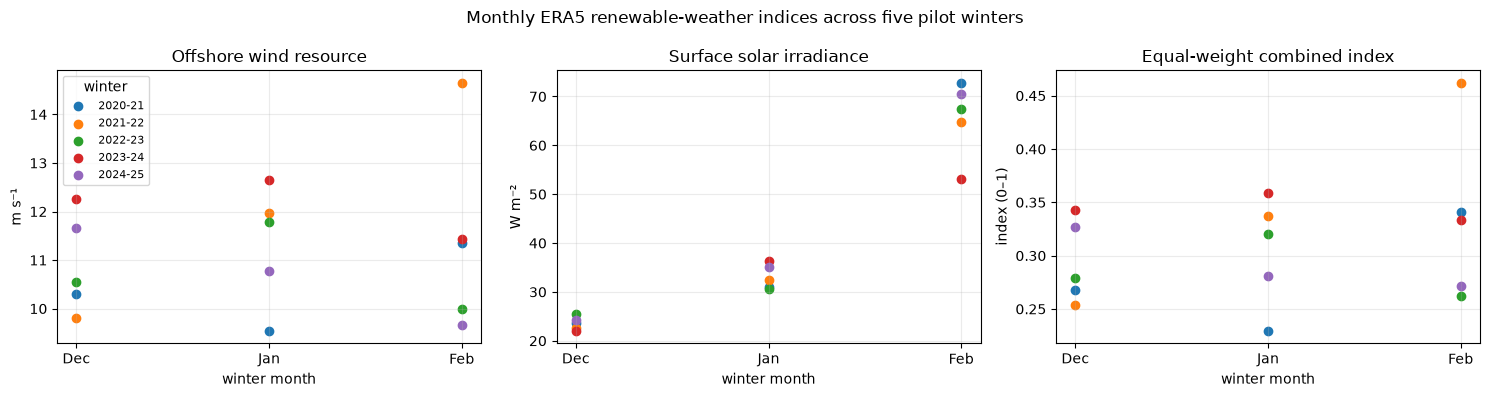

In [4]:
# Purpose: show whether winter-month averages hide very different wind and solar conditions.
monthly = (
    era5_hourly.groupby(["winter", "month"], as_index=False)
    .agg(
        wind_m_s=("wind_resource_m_s", "mean"),
        solar_w_m2=("solar_irradiance_w_m2", "mean"),
        combined_index=("combined_index", "mean"),
    )
)
month_order = ["Dec", "Jan", "Feb"]
monthly["month"] = pd.Categorical(monthly["month"], categories=month_order, ordered=True)
monthly = monthly.sort_values(["winter", "month"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, column, ylabel, title in [
    (axes[0], "wind_m_s", "m s⁻¹", "Offshore wind resource"),
    (axes[1], "solar_w_m2", "W m⁻²", "Surface solar irradiance"),
    (axes[2], "combined_index", "index (0–1)", "Equal-weight combined index"),
]:
    for winter, group in monthly.groupby("winter", observed=True):
        ax.scatter(group["month"].astype(str), group[column], label=winter)
    ax.set_title(title)
    ax.set_xlabel("winter month")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
axes[0].legend(title="winter", fontsize=8)
fig.suptitle("Monthly ERA5 renewable-weather indices across five pilot winters")
fig.tight_layout()
plt.show()


**Figure interpretation:** the three panels answer three different questions: was the offshore wind resource weak, was surface solar input weak, and were both weak together? Points are intentionally not connected: December, January, and February are separate monthly summaries, not a continuous forecast curve. These are weather-resource averages; they are not observed generation.

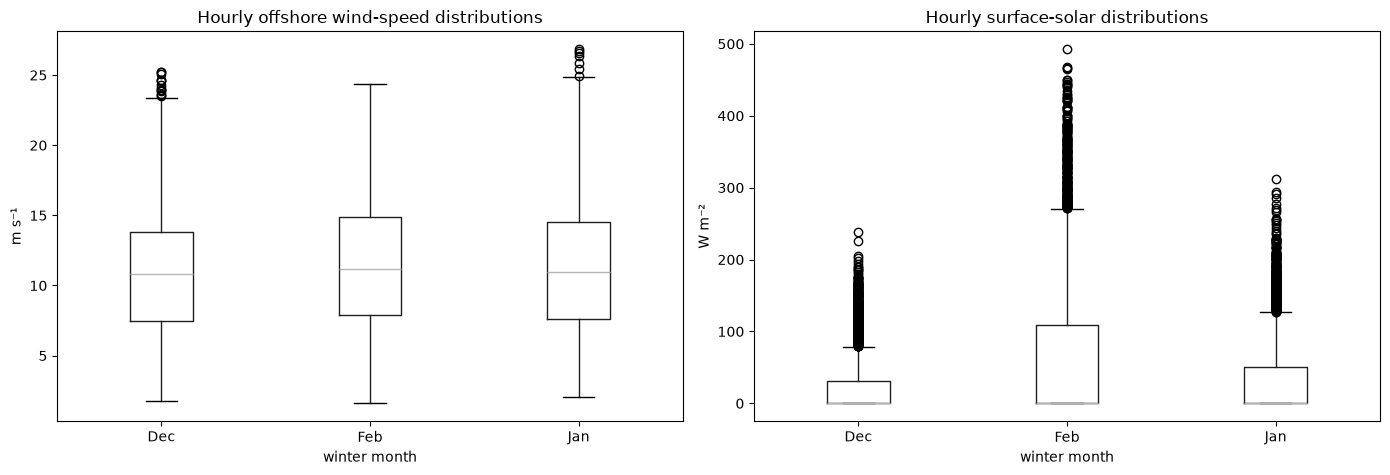

In [5]:
# Purpose: compare the full hourly distributions with the monthly means.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
era5_hourly.boxplot(column="wind_resource_m_s", by="month", ax=axes[0], grid=False)
era5_hourly.boxplot(column="solar_irradiance_w_m2", by="month", ax=axes[1], grid=False)
axes[0].set_title("Hourly offshore wind-speed distributions")
axes[0].set_xlabel("winter month")
axes[0].set_ylabel("m s⁻¹")
axes[1].set_title("Hourly surface-solar distributions")
axes[1].set_xlabel("winter month")
axes[1].set_ylabel("W m⁻²")
fig.suptitle("")
fig.tight_layout()
plt.show()


**What these distributions add:** a monthly mean can be identical for two months even when one has steady moderate conditions and the other alternates between calm and stormy periods. The boxes show the middle half of hourly values; the whiskers and points reveal broader extremes. Solar is expected to have many zero or near-zero winter-night values, so its mean is not a daylight-only value.

In [6]:
# Purpose: define a reproducible event detector for threshold sensitivity and minimum-duration sensitivity.
def contiguous_events(flag: np.ndarray, times: pd.Series, minimum_hours: int) -> list[dict]:
    values = np.asarray(flag, dtype=bool)
    events = []
    start = None
    for index, active in enumerate(np.r_[values, False]):
        if active and start is None:
            start = index
        if not active and start is not None:
            end = index
            hours = end - start
            if hours >= minimum_hours:
                events.append(
                    {
                        "start": times.iloc[start],
                        "end": times.iloc[end - 1],
                        "duration_hours": hours,
                        "n_hours": hours,
                    }
                )
            start = None
    return events

event_rows = []
for winter, group in era5_hourly.groupby("winter", sort=False):
    group = group.sort_values("time").reset_index(drop=True)
    for threshold in thresholds:
        for minimum_hours in durations:
            events = contiguous_events(
                group["combined_index"].to_numpy() < threshold,
                group["time"],
                minimum_hours,
            )
            event_rows.append(
                {
                    "winter": winter,
                    "threshold": threshold,
                    "minimum_duration_hours": minimum_hours,
                    "event_count": len(events),
                    "low_resource_hours": sum(event["n_hours"] for event in events),
                    "longest_event_hours": max((event["n_hours"] for event in events), default=0),
                }
            )

event_summary = pl.DataFrame(event_rows)
display(event_summary.with_columns(pl.col("threshold").round(2)))


winter,threshold,minimum_duration_hours,event_count,low_resource_hours,longest_event_hours
str,f64,i64,i64,i64,i64
"""2020-21""",0.05,24,0,0,0
"""2020-21""",0.05,48,0,0,0
"""2020-21""",0.05,72,0,0,0
"""2020-21""",0.1,24,6,258,58
"""2020-21""",0.1,48,2,108,58
…,…,…,…,…,…
"""2024-25""",0.15,48,2,154,90
"""2024-25""",0.15,72,1,90,90
"""2024-25""",0.2,24,14,667,95


### How to read the threshold table

The **threshold** asks how low the combined weather index must be before we call a period “low renewable resource.” A threshold of 0.05 is very strict; 0.20 is more permissive. The **minimum duration** prevents a single short dip from being treated as a system-relevant event. `event_count` counts separate episodes, `low_resource_hours` counts all hours inside those episodes, and `longest_event_hours` shows the most persistent episode. Changing the definitions changes the answer; that is why the sensitivity sweep is part of the result.

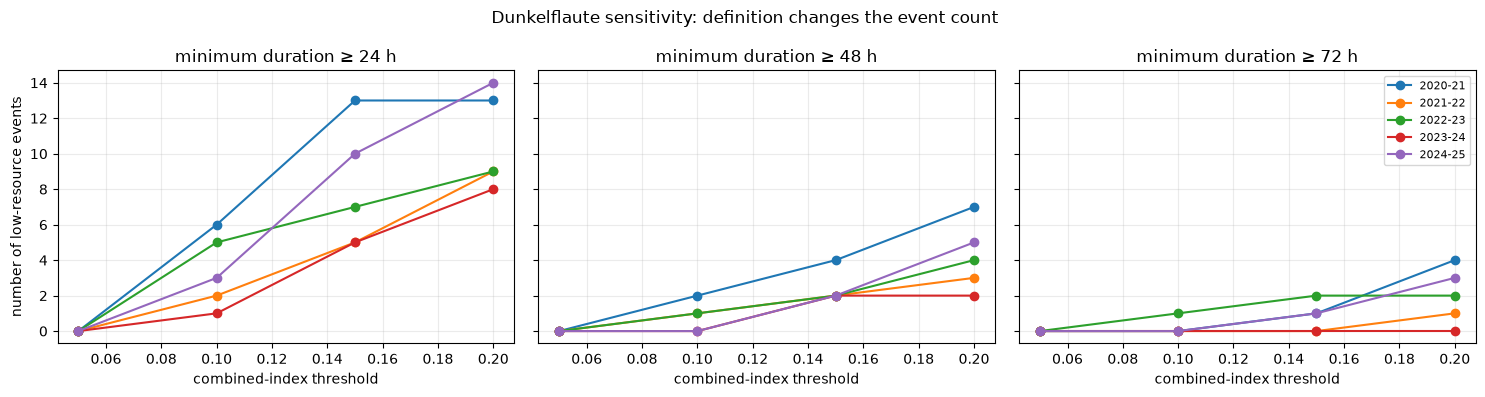

In [7]:
# Purpose: visualize how the number of detected low-resource episodes changes with both definitions.
plot_data = event_summary.to_pandas()
fig, axes = plt.subplots(1, len(durations), figsize=(15, 4), sharey=True)
for ax, minimum_hours in zip(axes, durations, strict=True):
    subset = plot_data[plot_data["minimum_duration_hours"] == minimum_hours]
    for winter, group in subset.groupby("winter"):
        ax.plot(group["threshold"], group["event_count"], marker="o", label=winter)
    ax.set_title(f"minimum duration ≥ {minimum_hours} h")
    ax.set_xlabel("combined-index threshold")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("number of low-resource events")
axes[-1].legend(fontsize=8)
fig.suptitle("Dunkelflaute sensitivity: definition changes the event count")
fig.tight_layout()
plt.show()


**Scientific reading:** this figure is not choosing a universal threshold. It shows how much the conclusion depends on the operational definition. A robust historical signal should not appear only for one narrow combination of threshold and duration.

In [8]:
# Purpose: load SMARD generation and installed capacity and build an observed wind-plus-solar comparison.
smard = SmardClient(cache_dir=ROOT / cfg["smard"]["cache_dir"])
observed_rows = []
for window in windows:
    start = datetime.fromisoformat(window["start"])
    end = datetime.fromisoformat(window["end"])
    generation = smard.load_generation(start, end, variables=["wind_offshore", "solar"])
    capacity = smard.load_installed_capacity(start, end, variables=["wind_offshore", "solar"])
    observed = capacity_factor(generation, capacity)
    observed_rows.append(observed)

observed_cf = pl.concat(observed_rows)
obs = observed_cf.to_pandas()
obs["time"] = pd.to_datetime(obs["time"], utc=True).dt.tz_convert(None)
obs = obs[obs["capacity_factor"].notna() & np.isfinite(obs["capacity_factor"])]
obs_pivot = obs.pivot_table(index="time", columns="variable", values="capacity_factor", aggfunc="mean")
obs_pivot["smard_equal_weight_index"] = obs_pivot[["wind_offshore", "solar"]].mean(axis=1)
display(
    pl.from_pandas(
        obs.groupby("variable", as_index=False).agg(
            hours=("time", "size"),
            mean_capacity_factor=("capacity_factor", "mean"),
            missing_fraction=("capacity_factor", lambda values: float(values.isna().mean())),
        )
    )
)


variable,hours,mean_capacity_factor,missing_fraction
str,i64,f64,f64
"""solar""",43296,0.030479,0.0
"""wind_offshore""",21648,0.476249,0.0


**Table guide:** `hours` counts valid SMARD records; `mean_capacity_factor` is generation divided by installed capacity, averaged over the available zones; and `missing_fraction` reports the share of missing values. Offshore wind has fewer records because offshore capacity is structurally absent in two TSO zones; that absence is not silently treated as zero generation.

**Observed comparison:** SMARD generation divided by installed capacity is a capacity factor for the published zone/technology aggregate. Offshore capacity is structurally absent in Amprion and TransnetBW, so the comparison uses the available 50Hertz and TenneT offshore observations plus solar. This is still not a plant-level benchmark, and the weather proxy and SMARD fleet do not have identical spatial footprints.

time,overlapping_hours,era5_mean,smard_mean,mean_difference
i32,i64,f64,f64,f64
2020,744,0.267,0.243,0.024
2021,2160,0.273,0.246,0.026
2022,2160,0.356,0.28,0.076
2023,2160,0.31,0.259,0.051
2024,2184,0.34,0.262,0.078
2025,1416,0.277,0.207,0.07


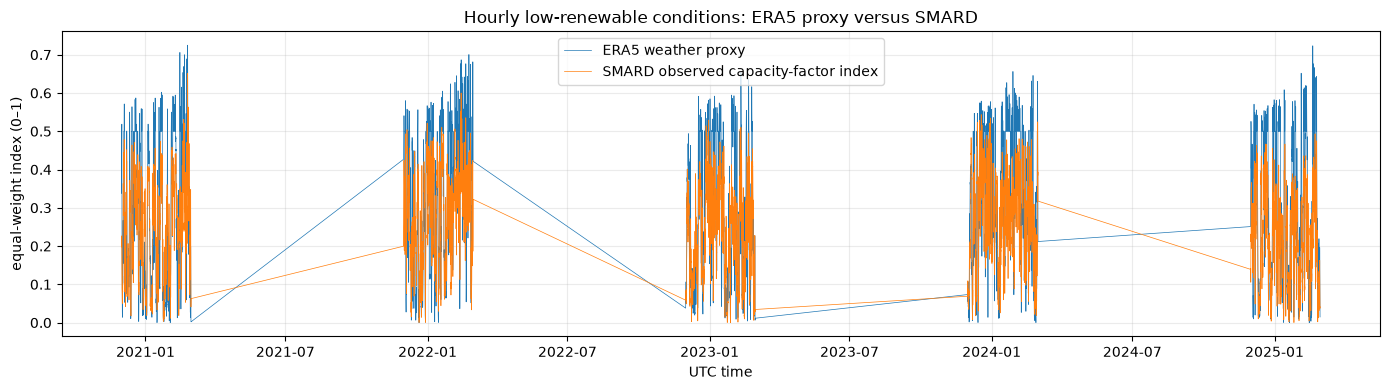

In [9]:
# Purpose: compare the ERA5 proxy and SMARD observed index at matching hourly timestamps.
era5_index = era5_hourly.set_index("time")["combined_index"].rename("era5_equal_weight_index")
comparison = pd.concat([era5_index, obs_pivot["smard_equal_weight_index"]], axis=1).dropna()
comparison["difference_era5_minus_smard"] = (
    comparison["era5_equal_weight_index"] - comparison["smard_equal_weight_index"]
)
display(
    pl.from_pandas(
        comparison.reset_index()
        .groupby(comparison.reset_index()["time"].dt.year, as_index=False)
        .agg(
            overlapping_hours=("era5_equal_weight_index", "size"),
            era5_mean=("era5_equal_weight_index", "mean"),
            smard_mean=("smard_equal_weight_index", "mean"),
            mean_difference=("difference_era5_minus_smard", "mean"),
        )
    ).with_columns(
        pl.col("era5_mean").round(3),
        pl.col("smard_mean").round(3),
        pl.col("mean_difference").round(3),
    )
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(comparison.index, comparison["era5_equal_weight_index"], lw=0.5, label="ERA5 weather proxy")
ax.plot(comparison.index, comparison["smard_equal_weight_index"], lw=0.5, label="SMARD observed capacity-factor index")
ax.set_title("Hourly low-renewable conditions: ERA5 proxy versus SMARD")
ax.set_xlabel("UTC time")
ax.set_ylabel("equal-weight index (0–1)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


**How to interpret the comparison:** agreement in timing would mean that the broad ERA5 weather proxy and the observed German aggregate tend to identify the same low-resource hours. A level difference is expected because the proxy uses simple boxes and equal weighting, while SMARD reflects actual fleet geography and operations. A mismatch is therefore scientifically useful: it identifies what the transparent proxy leaves out.

In [10]:
# Purpose: quantify how much the ERA5 low-resource events overlap with persistent TM1990 blocking labels on the required northern-margin domain.
blocking_z500 = {}
for window in windows:
    blocking_z500[window["label"]] = load_era5_z500(
        datetime.fromisoformat(window["start"]),
        datetime.fromisoformat(window["end"]),
        **cfg["blocking"]["domain"],
        cache_dir=cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
blocking_rows = []
for window in windows:
    winter = window["label"]
    result = detect_tm1990(
        blocking_z500[winter],
        phi0_deg=cfg["blocking"]["phi0_deg"],
        arm_deg=cfg["blocking"]["arm_deg"],
        scan_offsets_deg=tuple(cfg["blocking"]["scan_offsets_deg"]),
        ghgn_threshold_m_per_deg=cfg["blocking"]["ghgn_threshold_m_per_deg"],
        min_sector_width_deg=cfg["blocking"]["min_sector_width_deg"],
    )
    persistence = persistence_summary(
        result["blocking"],
        timestep_hours=cfg["era5"]["z500_stride_hours"],
        min_persistence_days=cfg["blocking"]["min_persistence_days"],
    )
    persistent = persistence["persistent_blocking"].reindex(
        time_z500=blocking_z500[winter].time_z500,
        method="nearest",
        tolerance=np.timedelta64(1, "h"),
    )
    blocking_rows.append(
        pd.DataFrame(
            {
                "time": pd.date_range(
                    start=window["start"],
                    end=pd.Timestamp(window["end"]) - pd.Timedelta(hours=1),
                    freq="h",
                ),
                "persistent_blocking": np.repeat(
                    persistent.values,
                    cfg["era5"]["z500_stride_hours"],
                )[: len(pd.date_range(
                    start=window["start"],
                    end=pd.Timestamp(window["end"]) - pd.Timedelta(hours=1),
                    freq="h",
                ))],
            }
        )
    )

blocking_hourly = pd.concat(blocking_rows, ignore_index=True).set_index("time")
era5_with_blocking = era5_hourly.set_index("time").join(blocking_hourly)
threshold = 0.10
low = era5_with_blocking["combined_index"] < threshold
overlap = era5_with_blocking.groupby("persistent_blocking")["combined_index"].agg(["count", "mean"])
display(pl.from_pandas(overlap.reset_index()).with_columns(pl.col("mean").round(3)))


persistent_blocking,count,mean
bool,i64,f64
false,9888,0.319
true,936,0.218


**Table guide:** `persistent_blocking` says whether an hourly timestamp belongs to a TM1990 blocking episode lasting at least five days; `count` is the number of matched hourly records; and `mean` is the average combined weather index for that group. A lower mean during blocking-labelled hours is an association in this pilot sample, not evidence of causation.

**Blocking interpretation:** the final table compares the combined weather index during hours labelled persistent-blocking and other hours. It is an association check. Even if the means differ, this five-winter analysis cannot show that blocking caused the renewable-weather conditions; both may reflect broader circulation variability, and the detector itself is a diagnostic definition.

In [11]:
# Purpose: summarize the pilot benchmark in a compact set of findings for a climate-science reader.
mean_proxy = era5_hourly["combined_index"].mean()
event_10_48 = event_summary.filter((pl.col("threshold") == 0.10) & (pl.col("minimum_duration_hours") == 48))
print(f"Mean ERA5 equal-weight weather index across the five winters: {mean_proxy:.3f}")
print("The 0.10 threshold and 48-hour duration are shown as one illustrative definition, not as a universal standard.")
display(event_10_48)


Mean ERA5 equal-weight weather index across the five winters: 0.310
The 0.10 threshold and 48-hour duration are shown as one illustrative definition, not as a universal standard.


winter,threshold,minimum_duration_hours,event_count,low_resource_hours,longest_event_hours
str,f64,i64,i64,i64,i64
"""2020-21""",0.1,48,2,108,58
"""2021-22""",0.1,48,1,56,56
"""2022-23""",0.1,48,1,93,93
"""2023-24""",0.1,48,0,0,0
"""2024-25""",0.1,48,0,0,0


## Findings, limitations, and next step

### What this benchmark establishes

* The existing ERA5 loader now supplies hourly `ssrd` alongside wind, pressure, and Z500, with the solar accumulation converted to W m⁻² and checked by the canonical contract.
* A transparent wind-plus-solar weather index can be calculated for all five pilot winters.
* Event counts and durations depend strongly on the threshold and persistence definition, so sensitivity is part of the scientific result.
* SMARD provides an observational comparison, but disagreement is expected because its fleet and operations are not represented by two static ERA5 boxes.

### What it does not establish

* It is not a German plant-level generation reconstruction.
* It is not a multi-decadal Dunkelflaute climatology.
* It does not prove that blocking causes low renewable output.
* `ssrd` is not labelled as a definitive photovoltaic GHI product here; panel orientation, albedo, temperature, and plant locations are absent.

### Recommended next step

Before touching EERIE or future projections, freeze the historical definitions after inspecting this notebook: choose a documented event threshold/duration, quantify the proxy–SMARD mismatch, and decide whether the historical benchmark is adequate for transfer to EERIE historical data.